In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [5]:
iris = sns.load_dataset('iris')

data = torch.tensor(iris[iris.columns[0:4]].values).float()

labels = torch.zeros(len(data), dtype=torch.long)

labels[iris.species=='versicolor'] = 1
labels[iris.species=='virginica'] = 2

In [6]:
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=.2)

train_data = torch.utils.data.TensorDataset(train_data, train_labels)
test_data = torch.utils.data.TensorDataset(test_data, test_labels)

batchsize = 16
train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [8]:
class theModelClass(nn.Module):
    def __init__(self, dropoutRate):
        super().__init__()

        self.input = nn.Linear(4, 12)
        self.hidden = nn.Linear(12, 12)
        self.output = nn.Linear(12, 3)

        self.dr = dropoutRate

    def forward(self, x):

        x = F.relu(self.input(x))
        x = F.dropout(x, p=self.dr, training=self.training)

        x = F.relu(self.hidden(x))
        x = F.dropout(x, p=self.dr, training=self.training)

        x = self.output(x)
        return x

In [9]:
tmpnet = theModelClass(.25)

tmpdata = torch.randn((10,4))
yhat = tmpnet(tmpdata)
yhat

tensor([[ 0.0901, -0.1054, -0.0329],
        [ 0.4422, -0.2949,  0.1605],
        [ 0.2806, -0.2064, -0.1219],
        [-0.0594, -0.2421,  0.2926],
        [ 0.1151, -0.5810,  0.4430],
        [ 0.1277, -0.0581,  0.0886],
        [ 0.2122, -0.0831, -0.0198],
        [ 0.3939, -0.4581, -0.1335],
        [ 0.4184, -0.2446,  0.2028],
        [ 0.1629, -0.3174,  0.0700]], grad_fn=<AddmmBackward0>)

In [19]:
def createANewModel(dropoutrate):
    ANNiris = theModelClass(dropoutrate)

    lossfun = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(ANNiris.parameters(), lr=.005)

    return ANNiris, lossfun, optimizer

In [26]:
numepochs = 500

def trainTheModel():

    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        ANNiris.train()

        batchAcc = []
        for X, y in train_loader:

            yHat = ANNiris(X)
            loss = lossfun(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchAcc.append(100*torch.mean((torch.argmax(yHat, axis=1)==y).float()).item())

        trainAcc.append(np.mean(batchAcc))

        ANNiris.eval()
        X, y = next(iter(test_loader))
        predlabels = torch.argmax(ANNiris(X), axis=1)
        testAcc.append(100*torch.mean((predlabels==y).float()).item())

    return trainAcc, testAcc

In [27]:
dropoutrate = .0
ANNiris, lossfun, optimizer = createANewModel(dropoutrate)

trainAcc, testAcc = trainTheModel()

AttributeError: 'float' object has no attribute 'items'

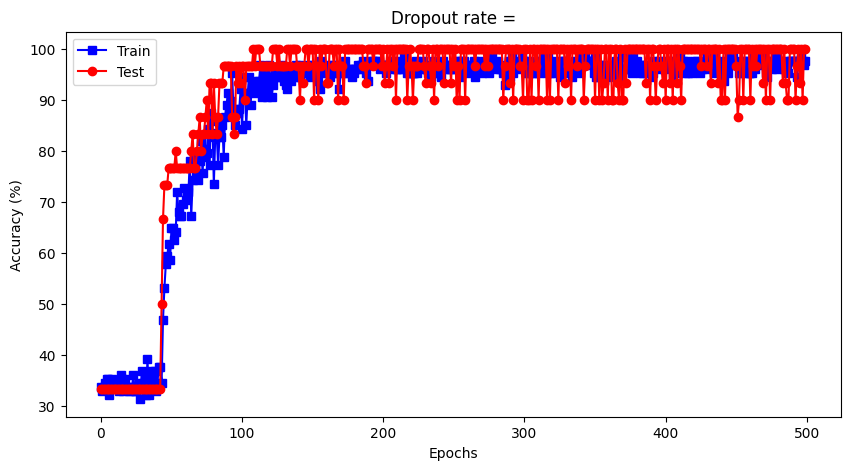

In [31]:
fig = plt.figure(figsize=(10,5))

plt.plot(trainAcc, 'bs-')
plt.plot(testAcc, 'ro-')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(['Train', 'Test'])
plt.title('Dropout rate =', dropoutrate)

plt.show()

In [33]:
dropoutRates = np.arange(10)/10
results = np.zeros((len(dropoutRates),2))

for di in range(len(dropoutRates)):

    ANNiris, lossfun, optimizer = createANewModel(dropoutRates[di])
    trainAcc, testAcc = trainTheModel()

    results[di, 0] = np.mean(trainAcc[-50:])
    results[di, 1] = np.mean(testAcc[-50:])

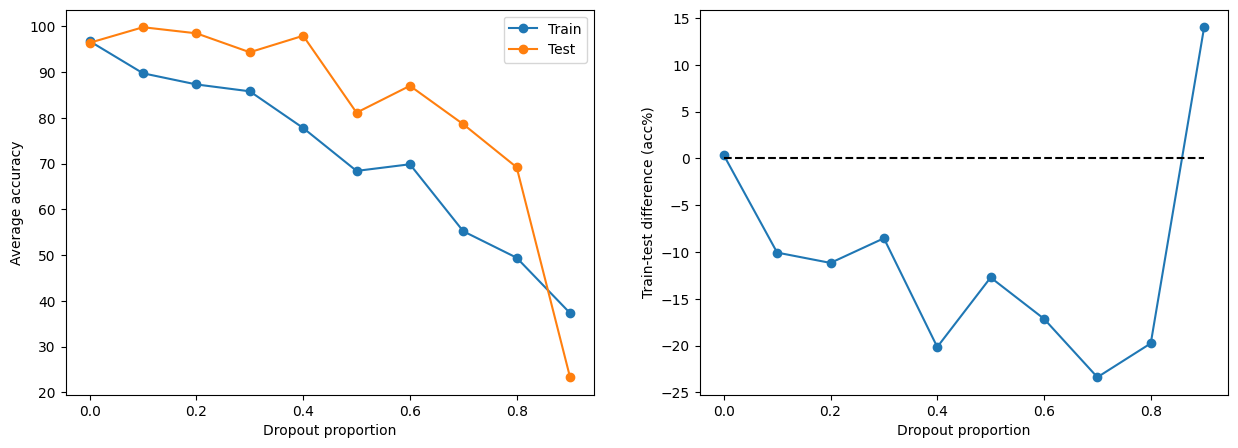

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(dropoutRates, results, 'o-')
ax[0].set_xlabel('Dropout proportion')
ax[0].set_ylabel('Average accuracy')
ax[0].legend(['Train', 'Test'])

ax[1].plot(dropoutRates, -np.diff(results, axis=1), 'o-')
ax[1].plot([0, .9], [0,0], 'k--')
ax[1].set_xlabel('Dropout proportion')
ax[1].set_ylabel('Train-test difference (acc%)')

plt.show()